<a href="https://colab.research.google.com/github/np03cs4a240301-sudo/ConceptandTechnologyofAI/blob/main/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/regression.csv')

# Display basic info
print("Dataset Head:\n", df.head())
print("\nInfo:\n", df.info())
print("\nDescription:\n", df.describe())

# Check for missing values
print("\nMissing values:\n", df.isnull().sum())
df = df.dropna()

Dataset Head:
    PackID  Cycle  Capacity   Voltage   Current  Temperature       SoH  \
0       1      1  0.000000  4.173140  1.087519    30.114693  0.974948   
1       1      1  0.020408  4.146588  1.169355    30.114693  0.974948   
2       1      1  0.040816  4.170401  1.225083    30.114693  0.974948   
3       1      1  0.061224  4.121798  1.159234    30.114693  0.974948   
4       1      1  0.081633  4.118776  1.232185    30.114693  0.974948   

        ICA       DVA  
0  0.000000  0.000000  
1 -0.768613 -1.301044  
2  0.857006  1.166852  
3 -0.419893 -2.381559  
4 -6.753907 -0.148062  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PackID       30000 non-null  int64  
 1   Cycle        30000 non-null  int64  
 2   Capacity     30000 non-null  float64
 3   Voltage      30000 non-null  float64
 4   Current      30000 non-null  float64


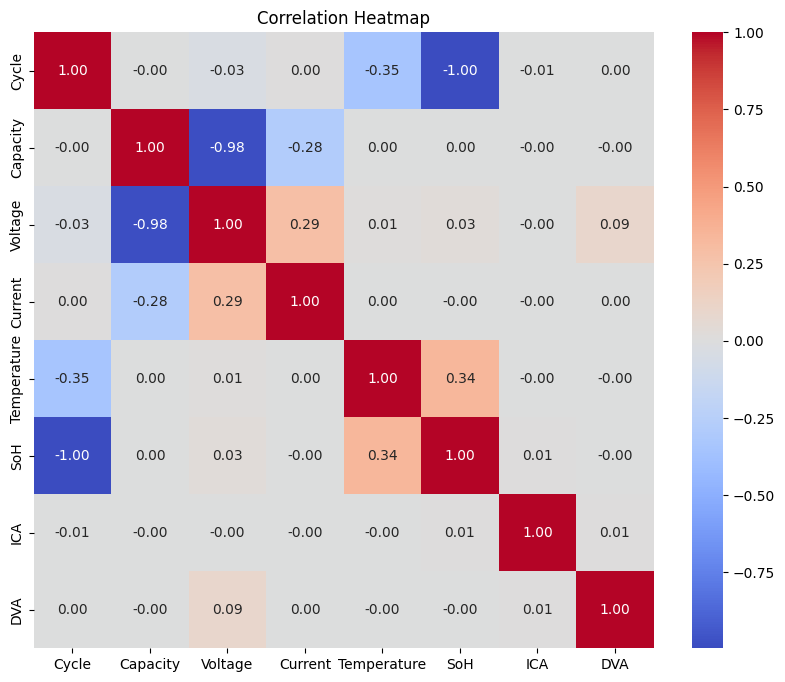

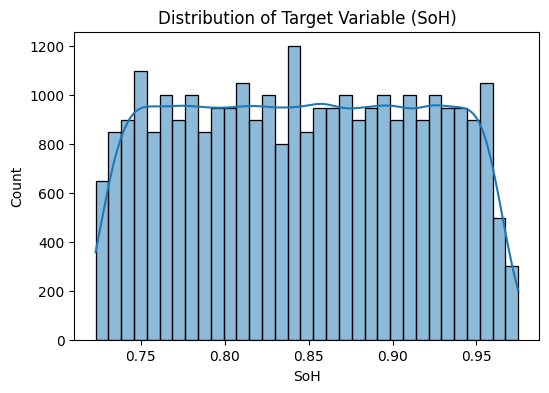

In [ ]:
# 2. Exploratory Data Analysis (EDA)
# Drop identifiers that are not useful for prediction (e.g., PackID)
if 'PackID' in df.columns:
    df = df.drop('PackID', axis=1)

# Visualization: Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Visualization: Distribution of Target (SoH)
plt.figure(figsize=(6, 4))
sns.histplot(df['SoH'], kde=True)
plt.title("Distribution of Target Variable (SoH)")
plt.show()



In [ ]:
year_cols = df.columns[4:]

df[year_cols] = df[year_cols].apply(pd.to_numeric, errors='coerce')

a = df.fillna(df.mean(), inplace=True)
a

In [ ]:
# Features and target
X = df.drop('SoH', axis=1)
y = df['SoH']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build NN
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # regression output
])

nn_model.compile(optimizer='adam', loss='mse')
history = nn_model.fit(X_train_scaled, y_train, epochs=50, validation_split=0.2, verbose=0)

# Evaluate NN
y_pred_nn = nn_model.predict(X_test_scaled)
print("NN MSE:", mean_squared_error(y_test, y_pred_nn))
print("NN R²:", r2_score(y_test, y_pred_nn))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
NN MSE: 4.488910455838563e-05
NN R²: 0.9906344709452498


In [ ]:
# 2. Neural Network Model
# ==========================================
print("\n--- 2. Neural Network Model ---")
# Define Features (X) and Target (y)
X = df.drop('SoH', axis=1)
y = df['SoH']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (Critical for NN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build NN
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # Linear output for regression
])

nn_model.compile(optimizer='adam', loss='mse')
history = nn_model.fit(X_train_scaled, y_train, epochs=20, validation_split=0.2, verbose=0)

# Evaluate NN
y_pred_nn = nn_model.predict(X_test_scaled)
print(f"NN MSE: {mean_squared_error(y_test, y_pred_nn):.4f}")
print(f"NN R²: {r2_score(y_test, y_pred_nn):.4f}")


--- 2. Neural Network Model ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
NN MSE: 0.0007
NN R²: 0.8519


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



# 3. Train/Test Split
X = df.drop('SoH', axis=1)   # 'SoH' is the actual target column
y = df['SoH']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

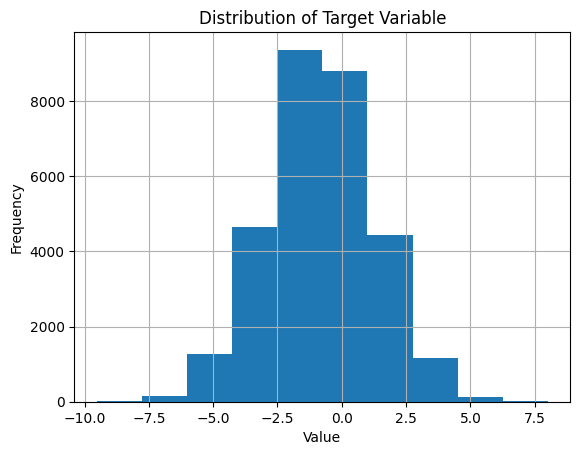

In [ ]:
plt.figure()
df[year_cols[-1]].hist()
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of Target Variable")
plt.show()


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error, r2_score

# 4. Neural Network Model
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # regression output
])

nn_model.compile(optimizer='adam', loss='mse')
history = nn_model.fit(X_train, y_train, epochs=50, validation_split=0.2, verbose=0)

# Evaluate NN
y_pred_nn = nn_model.predict(X_test)
print("NN MSE:", mean_squared_error(y_test, y_pred_nn))
print("NN R²:", r2_score(y_test, y_pred_nn))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
NN MSE: 5.710583069943853e-06
NN R²: 0.9988085609595629


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 5. Classical ML Models

# Features: all years except last
X = df[year_cols[:-1]]

# Target: last year
y = df[year_cols[-1]]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Scale features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Initialize Linear Regression model
model = LinearRegression()
# Train model using training data
model.fit(X_train, y_train)

# Predict target values
y_pred = model.predict(X_test)

# Evaluation metrics
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))



Mean Squared Error (MSE): 4.188013706760794
Mean Absolute Error (MAE): 1.618985303069779
R2 Score: -0.00047653020008353586


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# 6. Hyperparameter Optimization (example for RF)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42),
                           param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Best RF Params:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best RF Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.9999999966607792


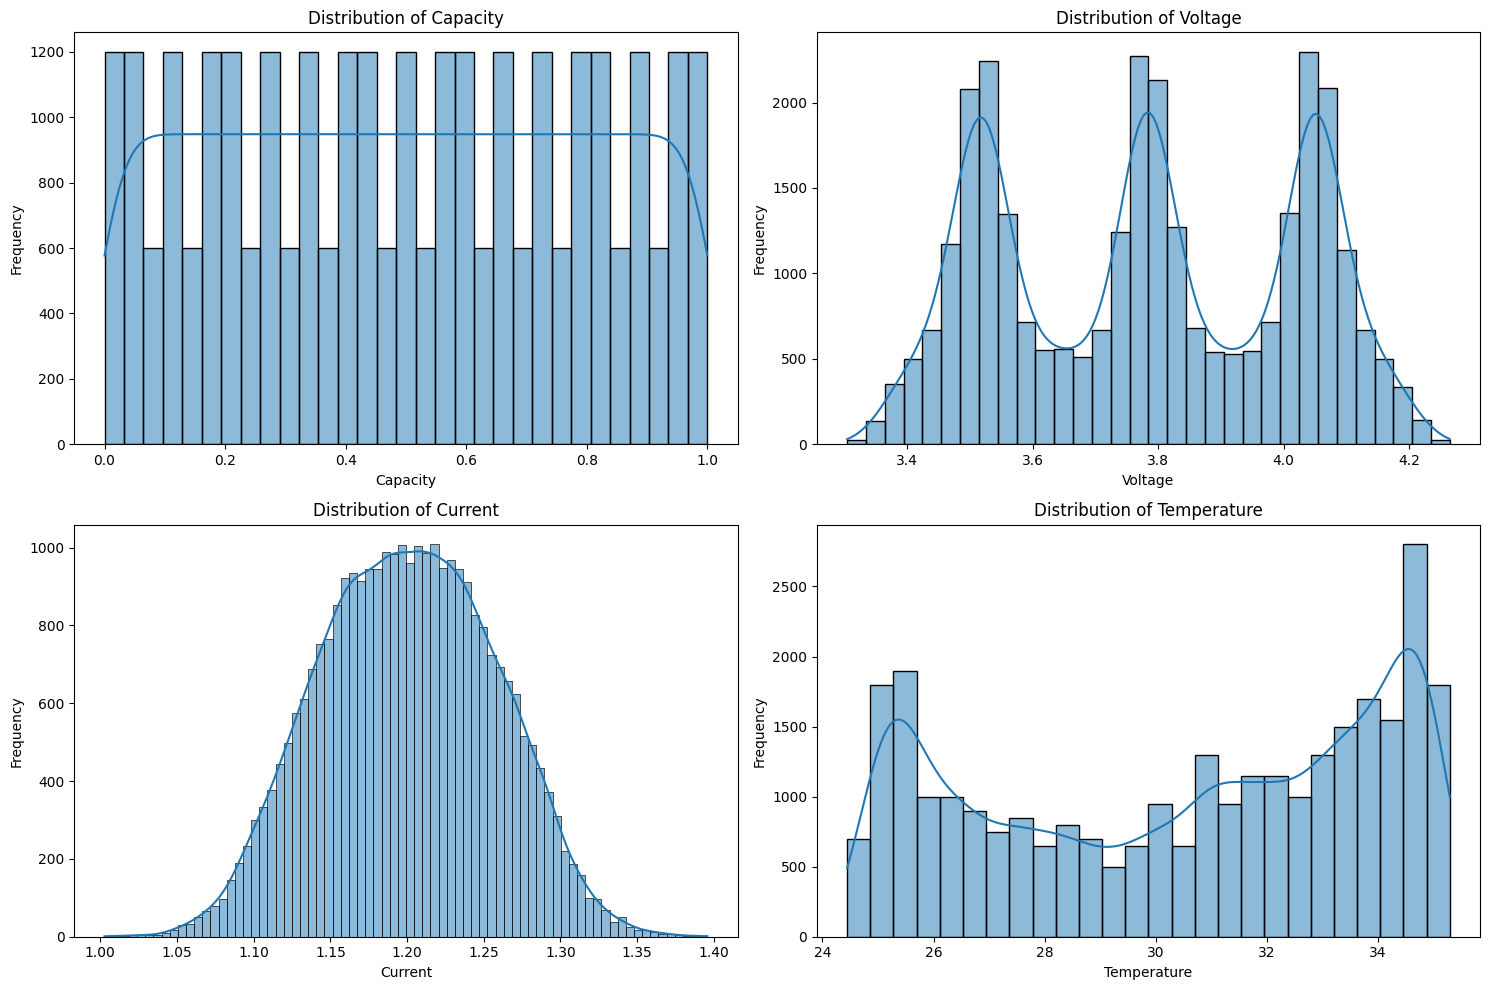

In [ ]:
features_to_plot = ['Capacity', 'Voltage', 'Current', 'Temperature']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 2, i + 1)  # Create a 2x2 grid of subplots
    sns.histplot(df[feature], kde=True) # Use histplot for distribution and KDE
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

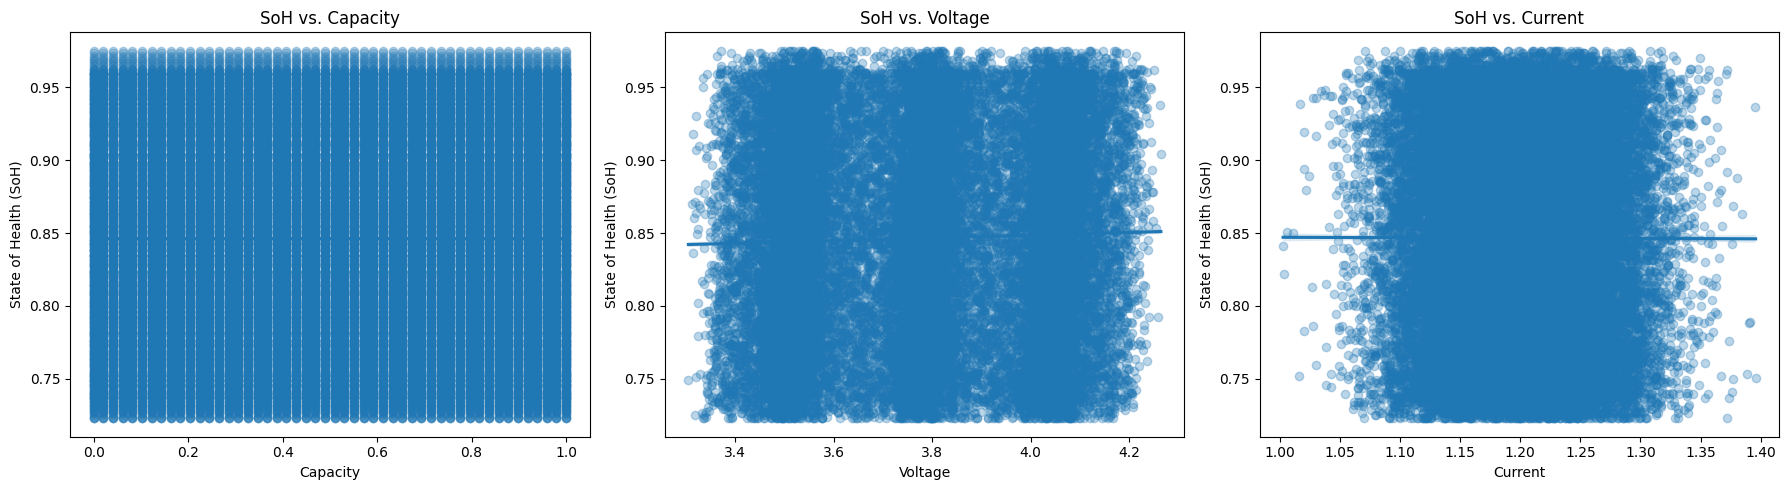

In [ ]:
features_to_correlate = ['Capacity', 'Voltage', 'Current']

plt.figure(figsize=(18, 5)) # Adjust figure size to accommodate 3 plots horizontally

for i, feature in enumerate(features_to_correlate):
    plt.subplot(1, 3, i + 1) # Create a 1x3 grid of subplots
    sns.regplot(data=df, x=feature, y='SoH', scatter_kws={'alpha':0.3})
    plt.title(f'SoH vs. {feature}')
    plt.xlabel(feature)
    plt.ylabel('State of Health (SoH)')

plt.tight_layout()
plt.show()